In [ ]:
class DualNumber:
    def __init__(self, value, der=1):
        self.value = value
        self.der = der
    
    def __add__(self, other):
        if not isinstance(other, DualNumber):
            return DualNumber(self.value + other, self.der)
        return DualNumber(self.value + other.value, self.der + other.der)
    def __mul__(self, other):
        if not isinstance(other, DualNumber):
            return DualNumber(self.value * other, self.der * other)
        return DualNumber(self.value * other.value,
                          self.value * other.der + self.der * other.value)
    def __neg__(self):
        return self * (-1)
    def __sub__(self, other):
        return self + (-other)
    def __pow__(self, n):
        return DualNumber(self.value ** n,
                          n * self.value**(n-1))
    __radd__ = __add__
    __rmul__ = __mul__
    __rsub__ = __sub__
    def __truediv__(self, other):
        return self * (other**-1)

x = DualNumber(2)

In [12]:
# Compute the first derivative of e^x cos(x) at x=1
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [13]:
x = tf.Variable(1.)
with tf.GradientTape() as tape:
    f = tf.exp(x) * tf.cos(x) # f(x)
    df_dx = tape.gradient(f, x)
    print(df_dx)

tf.Tensor(-0.81866133, shape=(), dtype=float32)


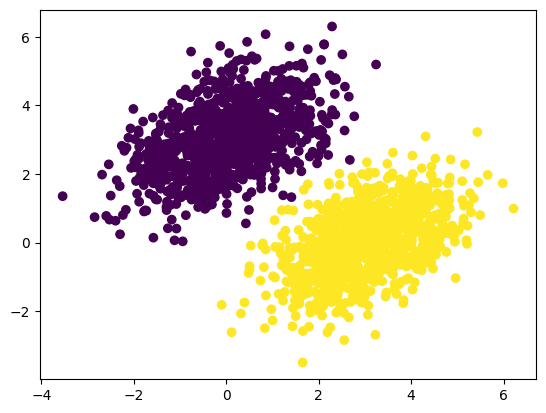

In [16]:
# Linear classifier in tf
n = 1000
set1 = np.random.multivariate_normal(mean=[0, 3], cov=[[1, 0.5],[0.5, 1]], size=n)
set2 = np.random.multivariate_normal(mean=[3, 0], cov=[[1, 0.5],[0.5, 1]], size=n)
inputs = np.vstack((set1,set2)).astype(np.float32)
targets = np.vstack((np.zeros((n,1), dtype="float32"),
                     np.ones((n,1), dtype="float32")))

plt.scatter(inputs[:,0], inputs[:,1], c=targets[:,0])
plt.show()

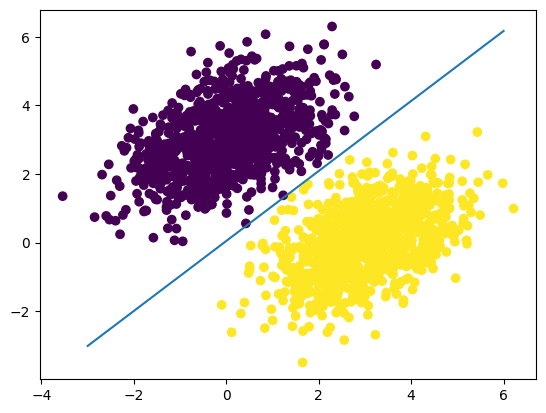

In [22]:
input_dim = 2
output_dim = 1
W = tf.Variable(tf.random.uniform(shape=(input_dim,output_dim)))
b = tf.Variable(tf.zeros(shape=(output_dim,)))
def model(inputs): # xW + b
    return tf.matmul(inputs, W) + b
def loss(targets, predictions):
    return tf.reduce_mean(tf.square(targets-predictions))
lr = 0.1
def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        L = loss(targets, predictions)
        dL_dW, dL_db = tape.gradient(L, [W, b])
        W.assign_sub(lr*dL_dW)
        b.assign_sub(lr*dL_db)
    return L

max_epoch = 100
L = np.zeros(max_epoch)
for epoch in range(max_epoch):
    L[epoch] = training_step(inputs, targets)
predictions = model(inputs)

x1 = np.linspace(-3, 6, 100)
x2 = (b-0.5-W[0]*x1)/W[1]
plt.scatter(inputs[:,0], inputs[:,1], c=predictions[:,0]>0.5)
plt.plot(x1,x2)

plt.show()